In [3]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import time
import pickle

In [4]:
sam_one = SAM()
sam_one.load_data('../../Subclustering/MNPO/SAM_Allen_Institute_MNPO.h5ad')

sam_two = SAM()
sam_two.load_data('../../Subclustering/MNPO/SAM_MO_soupx_plus5_cleaned_MNPO_07282026.h5ad')

sam_three = SAM()
sam_three.load_data('../../Subclustering/MNPO/SAM_CJ_joined_v2_cleaned_08182025_MNPO.h5ad')

sam_four = SAM()
sam_four.load_data('../../Subclustering/MNPO/SAM_AC_ncbi_soupx_cleaned_08182025_MNPO.h5ad')

sam_five = SAM()
sam_five.load_data('../../Subclustering/MNPO/SAM_RI_joined_cleaned_08032026_sssubclass_MNPO.h5ad')

In [5]:
sams = {'mg':sam_one,'mo':sam_two,'cj':sam_three,'ac':sam_four,'ri':sam_five}

sm = SAMAP(
    sams,
    f_maps = '../../BLASTMAPPING/maps/active_maps/hypo_proj/',
)

Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
Not updating the manifold...
20843 `mg` gene symbols match between the datasets and the BLAST graph.
18042 `mo` gene symbols match between the datasets and the BLAST graph.
15940 `cj` gene symbols match between the datasets and the BLAST graph.
20346 `ac` gene symbols match between the datasets and the BLAST graph.
21128 `ri` gene symbols match between the datasets and the BLAST graph.


In [6]:
sm.run(pairwise=True)

Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 17.98326826095581
Correcting data with means. 19.438685417175293
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 0 
Average alignment score (A.S.):  0.3982609166472442 
Max A.S. improvement: 0.785474428734623 
Min A.S. improvement: 0.0
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 13.891904354095459
Correcting data with means. 13.972814083099365
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...


/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1305: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs[i+'_'+k] = pd.Categorical(z)
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:1310: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  sam.adata.obs["batch"] = pd.Categorical(np.array(a))
/scratch/miniconda/lib/python3.7/site-packages/samap/mapping.py:969: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor pe

ITERATION: 1 
Average alignment score (A.S.):  0.4936218946096431 
Max A.S. improvement: 0.29030258336017956 
Min A.S. improvement: -0.13196390051909396
Calculating gene-gene correlations in the homology graph...
Prepping datasets for translation.
Translating feature spaces pairwise.
Projecting data into joint latent space. 13.6472909450531
Correcting data with means. 14.11748480796814
Expanding neighbourhoods of species mg...
Expanding neighbourhoods of species mo...
Expanding neighbourhoods of species cj...
Expanding neighbourhoods of species ac...
Expanding neighbourhoods of species ri...
Indegree coarsening
0/1 (0, 5183)
Rescaling edge weights by expression correlations.
Concatenating SAM objects...
ITERATION: 2 
Average alignment score (A.S.):  0.510312185841012 
Max A.S. improvement: 0.15764348475500298 
Min A.S. improvement: -0.11741079735817256
Alignment score --- 0.510312185841012
Running UMAP on the stitched manifolds.
Elapsed time: 4.7744262019793196 minutes.


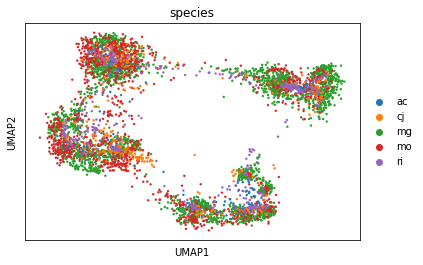

In [7]:
sc.pl.umap(sm.samap.adata, color = 'species')

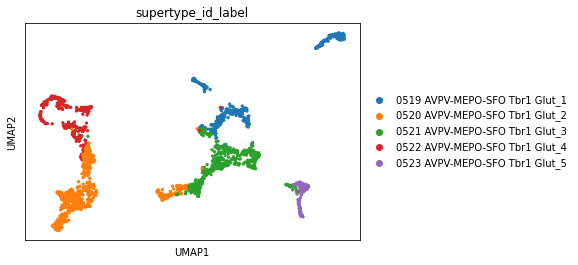

In [8]:
sc.pl.umap(sm.sams['mg'].adata, color = 'supertype_id_label')

In [9]:
save_samap(sm, '../../Subclustering/MNPO/sm_hypoorgs_MNPO_08042026.pkl')